In [26]:
import random
from dataclasses import dataclass

import pandas as pd
import numpy as np
from scipy.stats import wasserstein_distance
import torch

from personal_llm.utils import *

import matplotlib.pylab as plt

In [27]:
@dataclass
class Args:
    seed: int=0
    alpha: float=0.05
    n_persons: int=1000
    quantity_on_hand: int = 0
    worst_response: bool=False
    softmax: bool=False
    n_response: int=8

In [59]:
df = pd.read_csv("../data/rewarded_opinion_qa_(3).csv")
meta_df = pd.read_csv("../data/all_survey_q_and_a.csv")

In [60]:
df.columns, meta_df.columns

(Index(['Unnamed: 0', 'question', 'beaver_7b', 'gemma_2b', 'gemma_7b',
        'llama3_sfairx', 'mistral_raft', 'mistral_ray', 'mistral_weqweasdas',
        'oasst_deberta_v3', 'oasst_pythia_1b', 'oasst_pythia_7b', 'key',
        'option_mapping', 'references', 'option_ordinal', 'norm_option_ordinal',
        'norm_option_mapping'],
       dtype='object'),
 Index(['key', 'option_mapping', 'question', 'references', 'option_ordinal',
        'norm_option_ordinal', 'norm_option_mapping'],
       dtype='object'))

In [61]:
# df = df.merge(meta_df, right_on=["key"], left_on=["key"])

In [62]:
df

,Unnamed: 0,question,beaver_7b,gemma_2b,gemma_7b,llama3_sfairx,mistral_raft,mistral_ray,mistral_weqweasdas,oasst_deberta_v3,oasst_pythia_1b,oasst_pythia_7b,key,option_mapping,references,option_ordinal,norm_option_ordinal,norm_option_mapping
0,0,"How safe, if at all, would you say your local ...",0.333,0.333,0.333,0.000,1.0,0.333,0.333,0.333,1.000,0.000,SAFECRIME_W26,"{1.0: 'Very safe', 2.0: 'Somewhat safe', 3.0: ...","['Very safe', 'Somewhat safe', 'Not too safe',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very safe', 0.333: 'Somewhat safe', 0.6..."
1,1,"Compared to 50 years ago, do you think",0.000,1.000,0.000,0.000,0.5,0.000,0.500,0.500,0.500,0.500,WORLDDANGER_W26,"{1.0: 'We live in a safer world', 2.0: 'We liv...","['We live in a safer world', 'We live in a mor...","[1.0, 2.0, 1.5]","[0.0, 1.0, 0.5]","{0.0: 'We live in a safer world', 1.0: 'We liv..."
2,2,"How much, if at all, do you worry about the fo...",1.000,0.000,1.000,0.500,0.5,0.500,0.500,0.500,1.000,1.000,WORRYA_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1...."
3,3,"How much, if at all, do you worry about the fo...",1.000,0.000,0.000,0.500,0.5,1.000,0.500,0.500,1.000,1.000,WORRYB_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1...."
4,4,"How much, if at all, do you worry about the fo...",1.000,0.000,0.000,0.500,0.5,0.500,0.500,0.500,1.000,0.500,WORRYC_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,1501,When it comes to people who have immigrated to...,0.333,1.000,0.000,0.333,0.0,0.000,0.667,0.000,1.000,0.000,UNIMMIGCOMM_W92,"{1.0: 'A lot better', 2.0: 'A little better', ...","['A lot better', 'A little better', 'A little ...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'A lot better', 0.333: 'A little better'..."
1502,1502,"Regardless of your own religious beliefs, how ...",0.333,0.333,0.333,0.333,0.0,0.333,0.333,0.333,0.333,0.333,GODMORALIMP_W92,"{1.0: 'Essential', 2.0: 'Important, but not es...","['Essential', 'Important, but not essential', ...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Essential', 0.333: 'Important, but not ..."
1503,1503,How well does the Republican party represent t...,0.333,0.000,1.000,0.667,1.0,0.333,1.000,1.000,1.000,0.333,REPRSNTREP_W92,"{1.0: 'Very well', 2.0: 'Somewhat well', 3.0: ...","['Very well', 'Somewhat well', 'Not too well',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very well', 0.333: 'Somewhat well', 0.6..."
1504,1504,How well does the Democratic party represent t...,0.333,0.000,0.667,0.333,1.0,0.333,0.333,0.333,1.000,0.333,REPRSNTDEM_W92,"{1.0: 'Very well', 2.0: 'Somewhat well', 3.0: ...","['Very well', 'Somewhat well', 'Not too well',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very well', 0.333: 'Somewhat well', 0.6..."


In [63]:
args = Args()

_, reward_models = get_persons_and_reward_models()
n_rm = len(reward_models)

np.random.seed(args.seed)

random.seed(args.seed)
torch.manual_seed(args.seed)

alphas = np.array([args.alpha]*n_rm)
print("alphas", alphas)
persons = dirichlet.rvs(alphas, size=args.n_persons, random_state=args.seed)
print("persons", persons.shape)

alphas [0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
persons (1000, 10)


In [64]:
rm_choices = df[reward_models].to_numpy()
rm_choices.shape

(1506, 10)

In [65]:
all_choices = []

for person in persons:
    # print(person)
    # print(rm_choices[:2])

    scores = np.sum(rm_choices*person, -1)
    # print(scores[:2])
    # print(scores.shape)
    all_choices.append(scores)

all_choices = np.array(all_choices).T
all_choices.shape

(1506, 1000)

In [66]:
p_dists = []

for i in range(all_choices.shape[0]):

    survey_row = df.iloc[i]
    options = np.array(eval(survey_row["norm_option_ordinal"])).astype(float)
    
    q_responses = all_choices[i]
    p_dist = np.zeros(len(options))
    for j in range(args.n_persons):
        p_response = q_responses[j]
        # print(p_response)
        diffs = np.abs(options-p_response)
        vote = np.argmin(diffs)
        # print(diffs, vote)
        p_dist[vote] += 1
    
    p_dist = p_dist/args.n_persons
    p_dists.append(p_dist)

df["p_dist"] = p_dists

In [67]:
print(df.head())
df

   Unnamed: 0                                           question  beaver_7b  \
0           0  How safe, if at all, would you say your local ...      0.333   
1           1             Compared to 50 years ago, do you think      0.000   
2           2  How much, if at all, do you worry about the fo...      1.000   
3           3  How much, if at all, do you worry about the fo...      1.000   
4           4  How much, if at all, do you worry about the fo...      1.000   

   gemma_2b  gemma_7b  llama3_sfairx  mistral_raft  mistral_ray  \
0     0.333     0.333            0.0           1.0        0.333   
1     1.000     0.000            0.0           0.5        0.000   
2     0.000     1.000            0.5           0.5        0.500   
3     0.000     0.000            0.5           0.5        1.000   
4     0.000     0.000            0.5           0.5        0.500   

   mistral_weqweasdas  oasst_deberta_v3  oasst_pythia_1b  oasst_pythia_7b  \
0               0.333             0.333      

,Unnamed: 0,question,beaver_7b,gemma_2b,gemma_7b,llama3_sfairx,mistral_raft,mistral_ray,mistral_weqweasdas,oasst_deberta_v3,oasst_pythia_1b,oasst_pythia_7b,key,option_mapping,references,option_ordinal,norm_option_ordinal,norm_option_mapping,p_dist
0,0,"How safe, if at all, would you say your local ...",0.333,0.333,0.333,0.000,1.0,0.333,0.333,0.333,1.000,0.000,SAFECRIME_W26,"{1.0: 'Very safe', 2.0: 'Somewhat safe', 3.0: ...","['Very safe', 'Somewhat safe', 'Not too safe',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very safe', 0.333: 'Somewhat safe', 0.6...","[0.172, 0.615, 0.108, 0.105]"
1,1,"Compared to 50 years ago, do you think",0.000,1.000,0.000,0.000,0.5,0.000,0.500,0.500,0.500,0.500,WORLDDANGER_W26,"{1.0: 'We live in a safer world', 2.0: 'We liv...","['We live in a safer world', 'We live in a mor...","[1.0, 2.0, 1.5]","[0.0, 1.0, 0.5]","{0.0: 'We live in a safer world', 1.0: 'We liv...","[0.375, 0.083, 0.542]"
2,2,"How much, if at all, do you worry about the fo...",1.000,0.000,1.000,0.500,0.5,0.500,0.500,0.500,1.000,1.000,WORRYA_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1....","[0.077, 0.55, 0.373]"
3,3,"How much, if at all, do you worry about the fo...",1.000,0.000,0.000,0.500,0.5,1.000,0.500,0.500,1.000,1.000,WORRYB_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1....","[0.163, 0.474, 0.363]"
4,4,"How much, if at all, do you worry about the fo...",1.000,0.000,0.000,0.500,0.5,0.500,0.500,0.500,1.000,0.500,WORRYC_W26,"{1.0: 'Worry a lot', 2.0: 'Worry a little', 3....","['Worry a lot', 'Worry a little', 'Do not worr...","[1.0, 2.0, 3.0]","[0.0, 0.5, 1.0]","{0.0: 'Worry a lot', 0.5: 'Worry a little', 1....","[0.178, 0.658, 0.164]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,1501,When it comes to people who have immigrated to...,0.333,1.000,0.000,0.333,0.0,0.000,0.667,0.000,1.000,0.000,UNIMMIGCOMM_W92,"{1.0: 'A lot better', 2.0: 'A little better', ...","['A lot better', 'A little better', 'A little ...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'A lot better', 0.333: 'A little better'...","[0.425, 0.291, 0.16, 0.124]"
1502,1502,"Regardless of your own religious beliefs, how ...",0.333,0.333,0.333,0.333,0.0,0.333,0.333,0.333,0.333,0.333,GODMORALIMP_W92,"{1.0: 'Essential', 2.0: 'Important, but not es...","['Essential', 'Important, but not essential', ...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Essential', 0.333: 'Important, but not ...","[0.078, 0.922, 0.0, 0.0]"
1503,1503,How well does the Republican party represent t...,0.333,0.000,1.000,0.667,1.0,0.333,1.000,1.000,1.000,0.333,REPRSNTREP_W92,"{1.0: 'Very well', 2.0: 'Somewhat well', 3.0: ...","['Very well', 'Somewhat well', 'Not too well',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very well', 0.333: 'Somewhat well', 0.6...","[0.063, 0.3, 0.241, 0.396]"
1504,1504,How well does the Democratic party represent t...,0.333,0.000,0.667,0.333,1.0,0.333,0.333,0.333,1.000,0.333,REPRSNTDEM_W92,"{1.0: 'Very well', 2.0: 'Somewhat well', 3.0: ...","['Very well', 'Somewhat well', 'Not too well',...","[1.0, 2.0, 3.0, 4.0]","[0.0, 0.333, 0.667, 1.0]","{0.0: 'Very well', 0.333: 'Somewhat well', 0.6...","[0.08, 0.622, 0.183, 0.115]"


In [68]:
len(set(df["key"]))

1494

In [69]:
"ROBJOB7_W27" in df["key"]

False

In [70]:
df.to_csv("../data/opinion_qa_persona.csv", index=False)

In [14]:
human_responses = pd.read_csv("../data/human_responses.csv")
human_responses.head()

,Unnamed: 0,input_id,question_raw,question,references,context,mapping,top_k_logprobs,logprobs,probs_unnorm,...,model_name,model_order,attribute,group,D_H,R_H,group_order,WD,survey,Source
0,4748,id0,"How safe, if at all, would you say your local ...","How safe, if at all, would you say your local ...","['Very safe', 'Somewhat safe', 'Not too safe',...",NaN,"{'A': 'Very safe', 'B': 'Somewhat safe', 'C': ...","{' If': -13.072244, ' Whether': -12.861185, 'I...","[-5.1008224, -1.4846259, -8.522039, -8.398662,...",[6.09173466e-03 2.26587091e-01 1.99033183e-04 ...,...,text-davinci-003,11,Overall,Overall,[0.22466215 0.57038214 0.15717321 0.04778249],0.004699,0,0.149494,ATP 26,OpenAI
1,4809,id1,"Compared to 50 years ago, do you think","Compared to 50 years ago, do you think [We liv...","['We live in a safer world', 'We live in a mor...",NaN,"{'A': 'We live in a safer world', 'B': 'We liv...","{'It': -19.521576, ' An': -18.7429, ' :': -18....","[-6.086174, -9.932361, -0.0062259557, -11.616166]",[2.27409297e-03 4.85769704e-05 9.93793385e-01 ...,...,text-davinci-003,11,Overall,Overall,[0.09402386 0.69377638 0.21219976],0.005656,0,0.392734,ATP 26,OpenAI
2,4870,id2,"How much, if at all, do you worry about the fo...","How much, if at all, do you worry about the fo...","['Worry a lot', 'Worry a little', 'Do not worr...",NaN,"{'A': 'Worry a lot', 'B': 'Worry a little', 'C...","{' If': -18.012497, ' An': -16.812513, ' :': -...","[-0.097001284, -2.4153929, -8.674943, -13.353833]",[9.07554841e-01 8.93322334e-02 1.70812687e-04 ...,...,text-davinci-003,11,Overall,Overall,[0.19520973 0.54131148 0.2634788 ],0.000341,0,0.489165,ATP 26,OpenAI
3,4931,id3,"How much, if at all, do you worry about the fo...","How much, if at all, do you worry about the fo...","['Worry a lot', 'Worry a little', 'Do not worr...",NaN,"{'A': 'Worry a lot', 'B': 'Worry a little', 'C...","{' If': -18.777729, ' An': -19.786718, ' :': -...","[-8.345975, -4.7217026, -0.010841477, -9.059759]",[2.37349932e-04 8.90001248e-03 9.89217080e-01 ...,...,text-davinci-003,11,Overall,Overall,[0.15446245 0.42587239 0.41966516],0.000893,0,0.362704,ATP 26,OpenAI
4,4992,id4,"How much, if at all, do you worry about the fo...","How much, if at all, do you worry about the fo...","['Worry a lot', 'Worry a little', 'Do not worr...",NaN,"{'A': 'Worry a lot', 'B': 'Worry a little', 'C...","{' If': -16.090303, ' Whether': -17.450657, 'I...","[-1.9676399, -0.15379728, -8.748462, -12.20976]",[1.39786377e-01 8.57445825e-01 1.58705226e-04 ...,...,text-davinci-003,11,Overall,Overall,[0.18150375 0.43253789 0.38595836],0.002163,0,0.213575,ATP 26,OpenAI


In [171]:
def get_max_wd(ordered_ref_weights):
    d0, d1 = np.zeros(len(ordered_ref_weights)), np.zeros(len(ordered_ref_weights))
    d0[np.argmax(ordered_ref_weights)] = 1
    d1[np.argmin(ordered_ref_weights)] = 1
    max_wd = wasserstein_distance(ordered_ref_weights, ordered_ref_weights, d0, d1)
    return max_wd

dists = {"m":[],"p":[]}
for i in range(len(df)):
    try:
        # print("-----------")
        # print(i)
        p_row = df.iloc[i]
        q = p_row["question"]
        r = p_row["references"]

        h_resp = human_responses[(human_responses["question_raw"] == q) & (human_responses["references"] == r)]
        # print("check 0", len(h_resp))
        # assert(len(h_resp) == 1)
        h_resp = h_resp.iloc[0]
        # print("check 1")
        ord = eval(h_resp["ordinal"])
        # print("check 2")

        dh = h_resp["D_H"].replace("[", "").replace("]", "").rstrip().lstrip().split(" ")
        # print("check 3", i, dh)
        dh = np.array([float(x) for x in dh if len(x)])
        # print("check 4", i, dh)
        # print(dh)
        dm = h_resp["D_M"].replace("[", "").replace("]", "").rstrip().lstrip().split(" ")
        dm = np.array([float(x) for x in dm if len(x)])
        # dm = np.array([float(x) for x in h_resp["D_M"].replace("[", "").replace("]", "").split(" ")])
        dp = np.array(p_row["p_dist"])
        # print(dp)

        norm_factor = len(dp)-1

        # print(norm_factor)

        # print(dh, dm, dp)

        # print(h_resp)

        # dists["m"].append(1-wasserstein_distance(ord, ord, dh, dm)/norm_factor)
        # dists["p"].append(1-wasserstein_distance(ord, ord, dh, dp)/norm_factor)

        wd = 1-wasserstein_distance(ord, ord, dh, dm)/norm_factor
        dists["m"].append(wd)

        wd = 1-wasserstein_distance(ord, ord, dh, dp)/norm_factor
        dists["p"].append(wd)

        # print(dists["m"][-1])
        # print(dists["p"][-1])
        # break
    except Exception as e:
        print("Error", e)
        print(i)
        print(h_resp)
        # print("dh", dh)
        # print(type(dh))
        # print("dp", dp)
        # print(type(dp))
        # print("norm", norm_factor)
        # print("wd", wd)
        
        # print("------------")
        # print(p_row)
        # print("------------")
        # print(h_resp)
        print("------------")
        # break

In [172]:
len(dists["p"])

1454

In [173]:
print("Representativeness of GPT3:", np.mean(dists["m"]))
print("Representativeness of PersonalLLM models:", np.mean(dists["p"]))

Representativeness of GPT3: 0.7274275272126484
Representativeness of PersonalLLM models: 0.8392409964763398


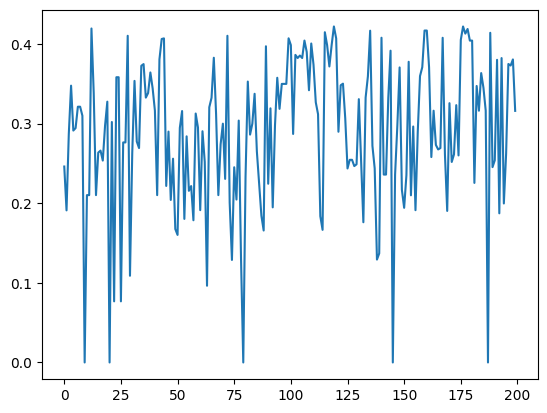

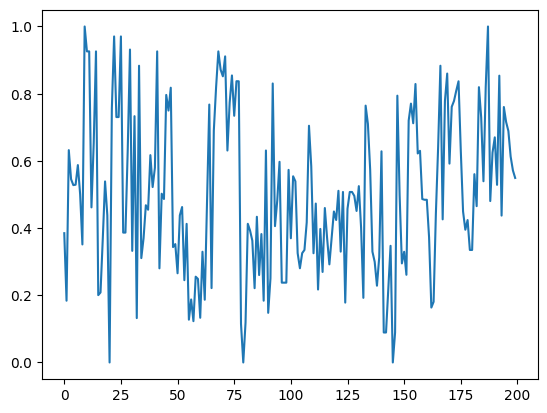

In [11]:
n_plot = 200
plt.plot(np.arange(n_plot), np.std(all_choices, -1)[:n_plot])
plt.show()

plt.plot(np.arange(n_plot), np.mean(all_choices, -1)[:n_plot])
plt.show()

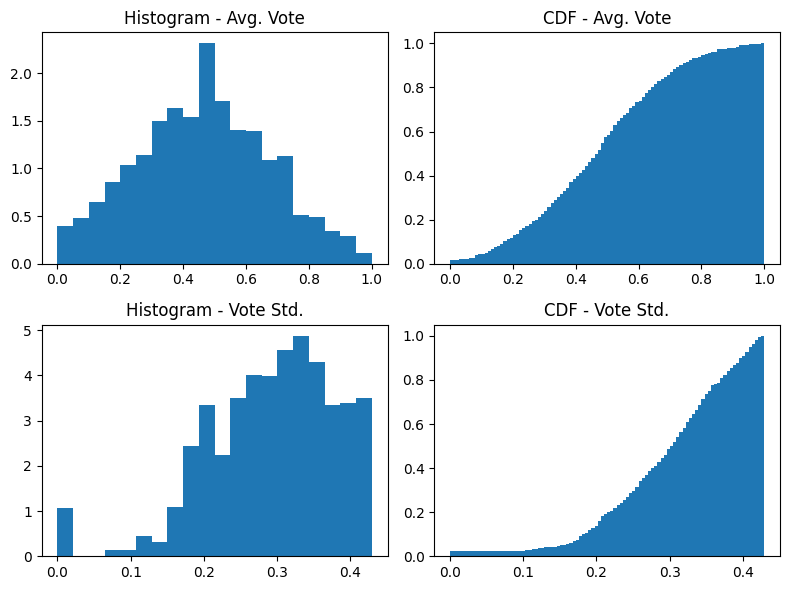

In [12]:
plt.rcParams["figure.figsize"] = (8,6)
fig, axs = plt.subplots(2,2)

axs[0,0].hist(np.mean(all_choices, -1), density=True, bins=20)
axs[0,0].set_title("Histogram - Avg. Vote")
axs[0,1].hist(np.mean(all_choices, -1), density=True, cumulative=True, bins=100)
axs[0,1].set_title("CDF - Avg. Vote")

axs[1,0].hist(np.std(all_choices, -1), density=True, bins=20)
axs[1,0].set_title("Histogram - Vote Std.")
axs[1,1].hist(np.std(all_choices, -1), density=True, cumulative=True, bins=100)
axs[1,1].set_title("CDF - Vote Std.")

fig.tight_layout()

plt.savefig("../plots/opinion_qa_density.png", bbox_inches="tight", dpi=300)
plt.show()

In [40]:
same_count = 0
one_answer = 0
for i in range(len(all_choices)):

    norm_options = eval(df.iloc[i]["norm_option_mapping"])

    if len(list(norm_options.keys())) == 1:
        one_answer += 1

    if len(set(list(all_choices[i]))) == 1:
        same_count += 1
        print("-", df.iloc[i]["question"])
        print("-", norm_options)

print("\nNo. one answer:", one_answer)
print("No. same:", same_count)

- Which of the following is the most important reason why you own a gun?
- {0.0: 'For my job'}
- What industry or field do you currently work in? If you have multiple jobs, please choose the one that you consider to be your main or primary occupation.
- {0.0: 'Not currently employed'}
- If robot caregivers such as these were developed, do you think the following are likely or not likely to happen as a result? Older adults would feel more independent and self-sufficient
- {0.0: 'Yes, likely', 1.0: 'No, not likely'}
- In your opinion, do you think government investments in basic scientific research usually pay off in the long run, or are they not worth it?
- {0.0: 'Government investments usually pay off in the long run', 1.0: "Government investments aren't worth it"}
- In your opinion, do you think government investments in medical research usually pay off in the long run, or are they not worth it?
- {0.0: 'Government investments usually pay off in the long run', 1.0: "Government investm

In [28]:
std = np.std(all_choices, -1)
mean = np.mean(all_choices, -1)


In [60]:
max_std_ind = np.argsort(-std)

n_print = 50
print("Most Disagreement (Highest Std.)")
for ind_idx, ind in enumerate(max_std_ind[:n_print]):
    
    norm_options = eval(df.iloc[ind]["norm_option_mapping"])
    if len(list(norm_options.keys())) == 1:
        continue

    print("#{}: ".format(ind_idx), df.iloc[ind]["question"])

    for k, v in norm_options.items():
        print(k, v)
    print(round(np.mean(all_choices[ind]), 3), "(", round(np.std(all_choices[ind]), 3), ")")
    print()


Most Disagreement (Highest Std.)
#0:  What should be the priority for dealing with illegal immigration in the U.S.?
0.0 Better border security and stronger enforcement of our immigration laws
1.0 Creating a way for immigrants already here illegally to become citizens if they meet certain requirements
0.5 Both should be given equal priority
0.446 ( 0.429 )

#1:  In general, would you say the following statements describes most research scientists well? Honest
0.0 Describes research scientists well
1.0 Does not describe research scientists well
0.516 ( 0.428 )

#2:  When it comes to racial discrimination, which do you think is the bigger problem for the country today?
0.0 People seeing racial discrimination where it really does not exist
1.0 People not seeing racial discrimination where it really does exist
0.444 ( 0.427 )

#3:  Still thinking ahead 30 years, which do you think is more likely to happen in the U.S.? The U.S. economy will be stronger/weaker
0.0 The U.S. economy will be str

In [27]:
min_std_ind = np.argsort(std)

n_print = 50
print("Least Disagreement (Lowest Std.)")
for ind_idx, ind in enumerate(min_std_ind[:n_print]):
    
    norm_options = eval(df.iloc[ind]["norm_option_mapping"])
    if len(list(norm_options.keys())) == 1:
        continue

    print("#{}: ".format(ind_idx), df.iloc[ind]["question"])
    
    for k, v in norm_options.items():
        print(k, v)
    print(round(np.mean(all_choices[ind]), 3), "(", round(np.std(all_choices[ind]), 3), ")")
    print()


Least Disagreement (Lowest Std.)
- How important is it that your smart speaker takes your personal interests and preferences into account when responding to your questions or commands?
0.0 Very important
0.333 Somewhat important
0.667 Not too important
1.0 Not important at all
0.0 ( 0.0 )

- In your opinion, do you think government investments in medical research usually pay off in the long run, or are they not worth it?
0.0 Government investments usually pay off in the long run
1.0 Government investments aren't worth it
0.0 ( 0.0 )

- Do you think adequate housing is something the federal government has a responsibility to provide for all Americans?
0.0 Yes, a responsibility of the federal government to provide for all Americans
1.0 No, not the responsibility of the federal government to provide
0.0 ( 0.0 )

- If robot caregivers such as these were developed, do you think the following are likely or not likely to happen as a result? Older adults would feel more independent and self-su

In [29]:
max_ind = np.argsort(-mean)

n_print = 50
print("Most Disagreement (Highest Std.)")
for ind_idx, ind in enumerate(max_ind[:n_print]):
    
    norm_options = eval(df.iloc[ind]["norm_option_mapping"])
    if len(list(norm_options.keys())) == 1:
        continue

    print("#{}: ".format(ind_idx), df.iloc[ind]["question"])
    
    for k, v in norm_options.items():
        print(k, v)
    print(round(np.mean(all_choices[ind]), 3), "(", round(np.std(all_choices[ind]), 3), ")")
    print()


Most Disagreement (Highest Std.)
- Would you prefer to live in a community where the houses are
0.0 Larger and farther apart, but schools, stores, and restaurants are several miles away
1.0 Smaller and closer to each other, but schools, stores, and restaurants are within walking distance
1.0 ( 0.0 )

- Now thinking about your own experiences have you ever personally received unwanted sexual advances or verbal or physical harassment of a sexual nature? This can be in any circumstance, whether or not work-related.
0.0 Yes
1.0 No
1.0 ( 0.0 )

- Do you think it's a good thing or a bad thing that most people in our society look down on women who are womanly or feminine?
0.0 Good thing
1.0 Bad thing
1.0 ( 0.0 )

- In the last 12 months, have you had someone take over your social media or email account without your permission
0.0 Yes
1.0 No
0.5 Offline: does not have internet
1.0 ( 0.0 )

- Do you personally own any guns (not including air guns, such as paintball, BB or pellet guns)?
0.0 Yes,

In [59]:
min_ind = np.argsort(mean)

n_print = 100
print("Most Disagreement (Highest Std.)")
for ind_idx, ind in enumerate(min_ind[:n_print]):
    
    norm_options = eval(df.iloc[ind]["norm_option_mapping"])
    if len(list(norm_options.keys())) == 1:
        continue

    print("#{}: ".format(ind_idx), df.iloc[ind]["question"])
    
    for k, v in norm_options.items():
        print(k, v)
    print(round(np.mean(all_choices[ind]), 3), "(", round(np.std(all_choices[ind]), 3), ")")
    print()


Most Disagreement (Highest Std.)
#0:  If robot caregivers such as these were developed, do you think the following are likely or not likely to happen as a result? Older adults would feel more independent and self-sufficient
0.0 Yes, likely
1.0 No, not likely
0.0 ( 0.0 )

#4:  When you hear about problems with professional misconduct among medical doctors, which comes closer to your view, even if neither is exactly right?
0.0 Most medical doctors have good intentions, it's the system that's broken
1.0 The system can work fine, it's the medical doctors that are the problem
0.0 ( 0.0 )

#5:  Which statement comes closer to your view?
0.0 Society is better off if couples who want to stay together long-term eventually get married
1.0 Society is just as well off if couples who want to stay together long-term decide not to marry
0.0 ( 0.0 )

#6:  When you hear about problems with research misconduct among nutrition research scientists, which comes closer to your view, even if neither is exact

In [56]:
topics = set(df["key"].tolist())

sub_topics = []
for t in topics:
    s = "_".join(t.split("_")[:-1])
    print(t, s)
    if s not in sub_topics:
        sub_topics.append(s)
    

# sub_topics = [ for t in topics]
print(len(sub_topics), sub_topics)
print(len(topics), topics)

FUD35_W34 FUD35
HAPPENj_W41 HAPPENj
RQ2_F1A_W42 RQ2_F1A
RACESURV37_W43 RACESURV37
SATLIFEB_W32 SATLIFEB
LOCALPROBC_W32 LOCALPROBC
SOCIETY_GUNS_W92 SOCIETY_GUNS
JOBSECURITY_W41 JOBSECURITY
PP6c_W49 PP6c
WORRYBILL_W29 WORRYBILL
RACESURV20_W43 RACESURV20
GUNRESPKIDSC_W26 GUNRESPKIDSC
SUCCESSIMPB_W32 SUCCESSIMPB
PQ8_F2A_W42 PQ8_F2A
FTRWORRYd_W41 FTRWORRYd
DEFENDGUN_W26 DEFENDGUN
AUTOWKPLC_W41 AUTOWKPLC
PQ3_F2Ab_W42 PQ3_F2Ab
SOURCESKEPb_W45 SOURCESKEPb
FAMSURV26c_W50 FAMSURV26c
SOCIETY_TRANS_W92 SOCIETY_TRANS
ROBWRK_W41 ROBWRK
FUD37B_W34 FUD37B
WORRYC_W26 WORRYC
RACESURV15b_W43 RACESURV15b
TRANSGEND3_W29 TRANSGEND3
GAP21Q33_h_W82 GAP21Q33_h
TRACKCO1b_W49 TRACKCO1b
AMNTWMNP2F1_W36 AMNTWMNP2F1
GUNRESPKIDSE_W26 GUNRESPKIDSE
MESUM1_FB_W29 MESUM1_FB
GAP21Q33_j_W82 GAP21Q33_j
HOMEASSIST4_W49 HOMEASSIST4
SCM5j_W42 SCM5j
INFOCREATEa_W45 INFOCREATEa
CARS7A_W27 CARS7A
GAP21Q29_W82 GAP21Q29
GUNRESPKIDSH_W26 GUNRESPKIDSH
G1_W34 G1
DB1c_W49 DB1c
WHYNOTPOLF1D_W36 WHYNOTPOLF1D
ROMRELSER_W50 ROMRELSER
RQ4_